# Data

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importing Data
URL = 'events.csv'
df = pd.read_csv(URL)

## Data Exploration

In [ ]:
print("Return first 5 rows.","\n")
df.head()

Return first 5 rows. 



,Start time UTC,End time UTC,Start time UTC+03:00,End time UTC+03:00,Electricity consumption in Finland
0,2015-12-31 21:00:00,2015-12-31 22:00:00,2016-01-01 00:00:00,2016-01-01 01:00:00,10800.0
1,2015-12-31 22:00:00,2015-12-31 23:00:00,2016-01-01 01:00:00,2016-01-01 02:00:00,10431.0
2,2015-12-31 23:00:00,2016-01-01 00:00:00,2016-01-01 02:00:00,2016-01-01 03:00:00,10005.0
3,2016-01-01 00:00:00,2016-01-01 01:00:00,2016-01-01 03:00:00,2016-01-01 04:00:00,9722.0
4,2016-01-01 01:00:00,2016-01-01 02:00:00,2016-01-01 04:00:00,2016-01-01 05:00:00,9599.0


In [ ]:
print("Return last 5 rows.","\n")
df.tail()

Return last 5 rows. 



,Start time UTC,End time UTC,Start time UTC+03:00,End time UTC+03:00,Electricity consumption in Finland
52961,2021-12-31 16:00:00,2021-12-31 17:00:00,2021-12-31 19:00:00,2021-12-31 20:00:00,11447.0
52962,2021-12-31 17:00:00,2021-12-31 18:00:00,2021-12-31 20:00:00,2021-12-31 21:00:00,11237.0
52963,2021-12-31 18:00:00,2021-12-31 19:00:00,2021-12-31 21:00:00,2021-12-31 22:00:00,10914.0
52964,2021-12-31 19:00:00,2021-12-31 20:00:00,2021-12-31 22:00:00,2021-12-31 23:00:00,10599.0
52965,2021-12-31 20:00:00,2021-12-31 21:00:00,2021-12-31 23:00:00,2022-01-01 00:00:00,10812.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52966 entries, 0 to 52965
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Start time UTC                      52966 non-null  object 
 1   End time UTC                        52966 non-null  object 
 2   Start time UTC+03:00                52966 non-null  object 
 3   End time UTC+03:00                  52966 non-null  object 
 4   Electricity consumption in Finland  52966 non-null  float64
dtypes: float64(1), object(4)
memory usage: 2.0+ MB


In [ ]:
#print("Descriptive statistics include those that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN values.", "\n")
print(df.describe(), "\n")

       Electricity consumption in Finland
count                        52966.000000
mean                          9488.750519
std                           1576.241673
min                           5341.000000
25%                           8322.000000
50%                           9277.000000
75%                          10602.000000
max                          15105.000000 



## Feature Extraction


In [ ]:
del df["Start time UTC"]
del df["End time UTC"]
del df["Start time UTC+03:00"]
df.rename(columns={"End time UTC+03:00":"DateTime","Electricity consumption in Finland":"Consumption"},inplace=True)
print(df.head(5))

              DateTime  Consumption
0  2016-01-01 01:00:00      10800.0
1  2016-01-01 02:00:00      10431.0
2  2016-01-01 03:00:00      10005.0
3  2016-01-01 04:00:00       9722.0
4  2016-01-01 05:00:00       9599.0


since we are dealing with time series data we should edite the index from 1 2 3 ... --> DateTime format.

In [ ]:
dataset = df
dataset["Month"] = pd.to_datetime(df["DateTime"]).dt.month
dataset["Year"] = pd.to_datetime(df["DateTime"]).dt.year
dataset["Date"] = pd.to_datetime(df["DateTime"]).dt.date
dataset["Time"] = pd.to_datetime(df["DateTime"]).dt.time
dataset["Week"] = pd.to_datetime(df["DateTime"]).dt.isocalendar().week
dataset["Day"] = pd.to_datetime(df["DateTime"]).dt.day_name()
dataset = df.set_index("DateTime")
dataset.index = pd.to_datetime(dataset.index)

In [ ]:
dataset.head()

,Consumption,Month,Year,Date,Time,Week,Day
DateTime,,,,,,,
2016-01-01 01:00:00,10800.0,1,2016,2016-01-01,01:00:00,53,Friday
2016-01-01 02:00:00,10431.0,1,2016,2016-01-01,02:00:00,53,Friday
2016-01-01 03:00:00,10005.0,1,2016,2016-01-01,03:00:00,53,Friday
2016-01-01 04:00:00,9722.0,1,2016,2016-01-01,04:00:00,53,Friday
2016-01-01 05:00:00,9599.0,1,2016,2016-01-01,05:00:00,53,Friday


In [ ]:
print("")
print("Total Number of Years: ", dataset.Year.nunique() )
print(dataset.Year.unique())


Total Number of Years:  7
[2016 2017 2018 2019 2020 2021 2022]


In [ ]:
# By assuming week starts on Mondey and ends on Sunday.
# The closest start would be on Monday 4-1-2016
# The closest end would be on sunday 26-12-2021
# So we should omit first 71 rows and last 121 rows.
dataset = dataset[71:-121]
dataset.tail()

,Consumption,Month,Year,Date,Time,Week,Day
DateTime,,,,,,,
2021-12-26 19:00:00,12550.0,12,2021,2021-12-26,19:00:00,51,Sunday
2021-12-26 20:00:00,12622.0,12,2021,2021-12-26,20:00:00,51,Sunday
2021-12-26 21:00:00,12574.0,12,2021,2021-12-26,21:00:00,51,Sunday
2021-12-26 22:00:00,12384.0,12,2021,2021-12-26,22:00:00,51,Sunday
2021-12-26 23:00:00,12044.0,12,2021,2021-12-26,23:00:00,51,Sunday


## Data Visualizations

<ipython-input-13-5d8d0488214e>:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


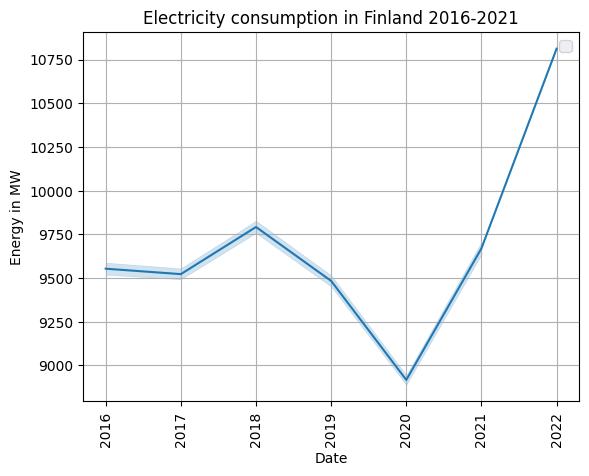

In [ ]:
from matplotlib import style
fig = plt.figure()
axes1 = plt.subplot2grid((1,1), (0,0))

style.use("ggplot")
sns.lineplot(x= dataset["Year"], y= dataset["Consumption"], data = dataset)
sns.set(rc={'figure.figsize': (20,10)})

plt.title("Electricity consumption in Finland 2016-2021")
plt.xlabel("Date")
plt.ylabel("Energy in MW")
plt.grid(True)
plt.legend()

for label in axes1.xaxis.get_ticklabels():
    label.set_rotation(90)


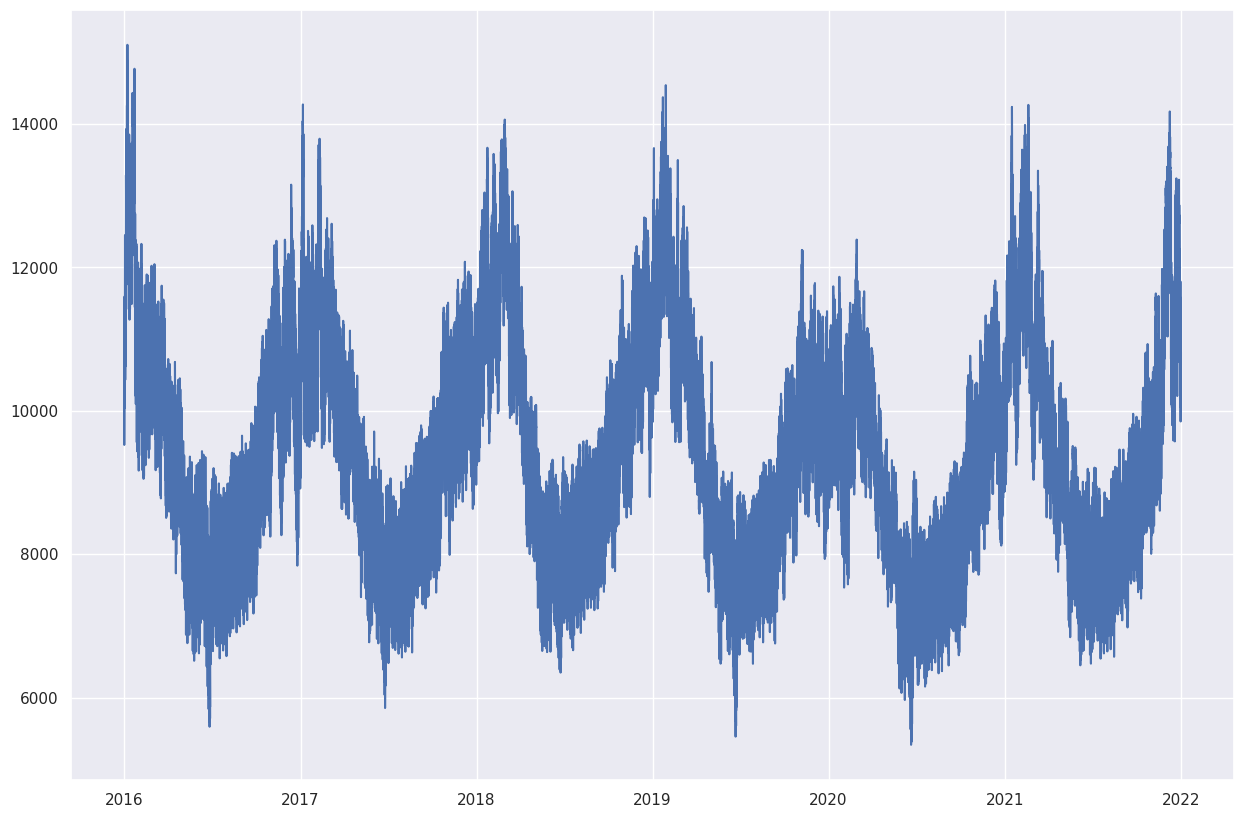

In [ ]:
plt.figure(figsize=(15,10))
plt.plot(dataset["Consumption"])

<ipython-input-15-4faa2ecb455f>:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


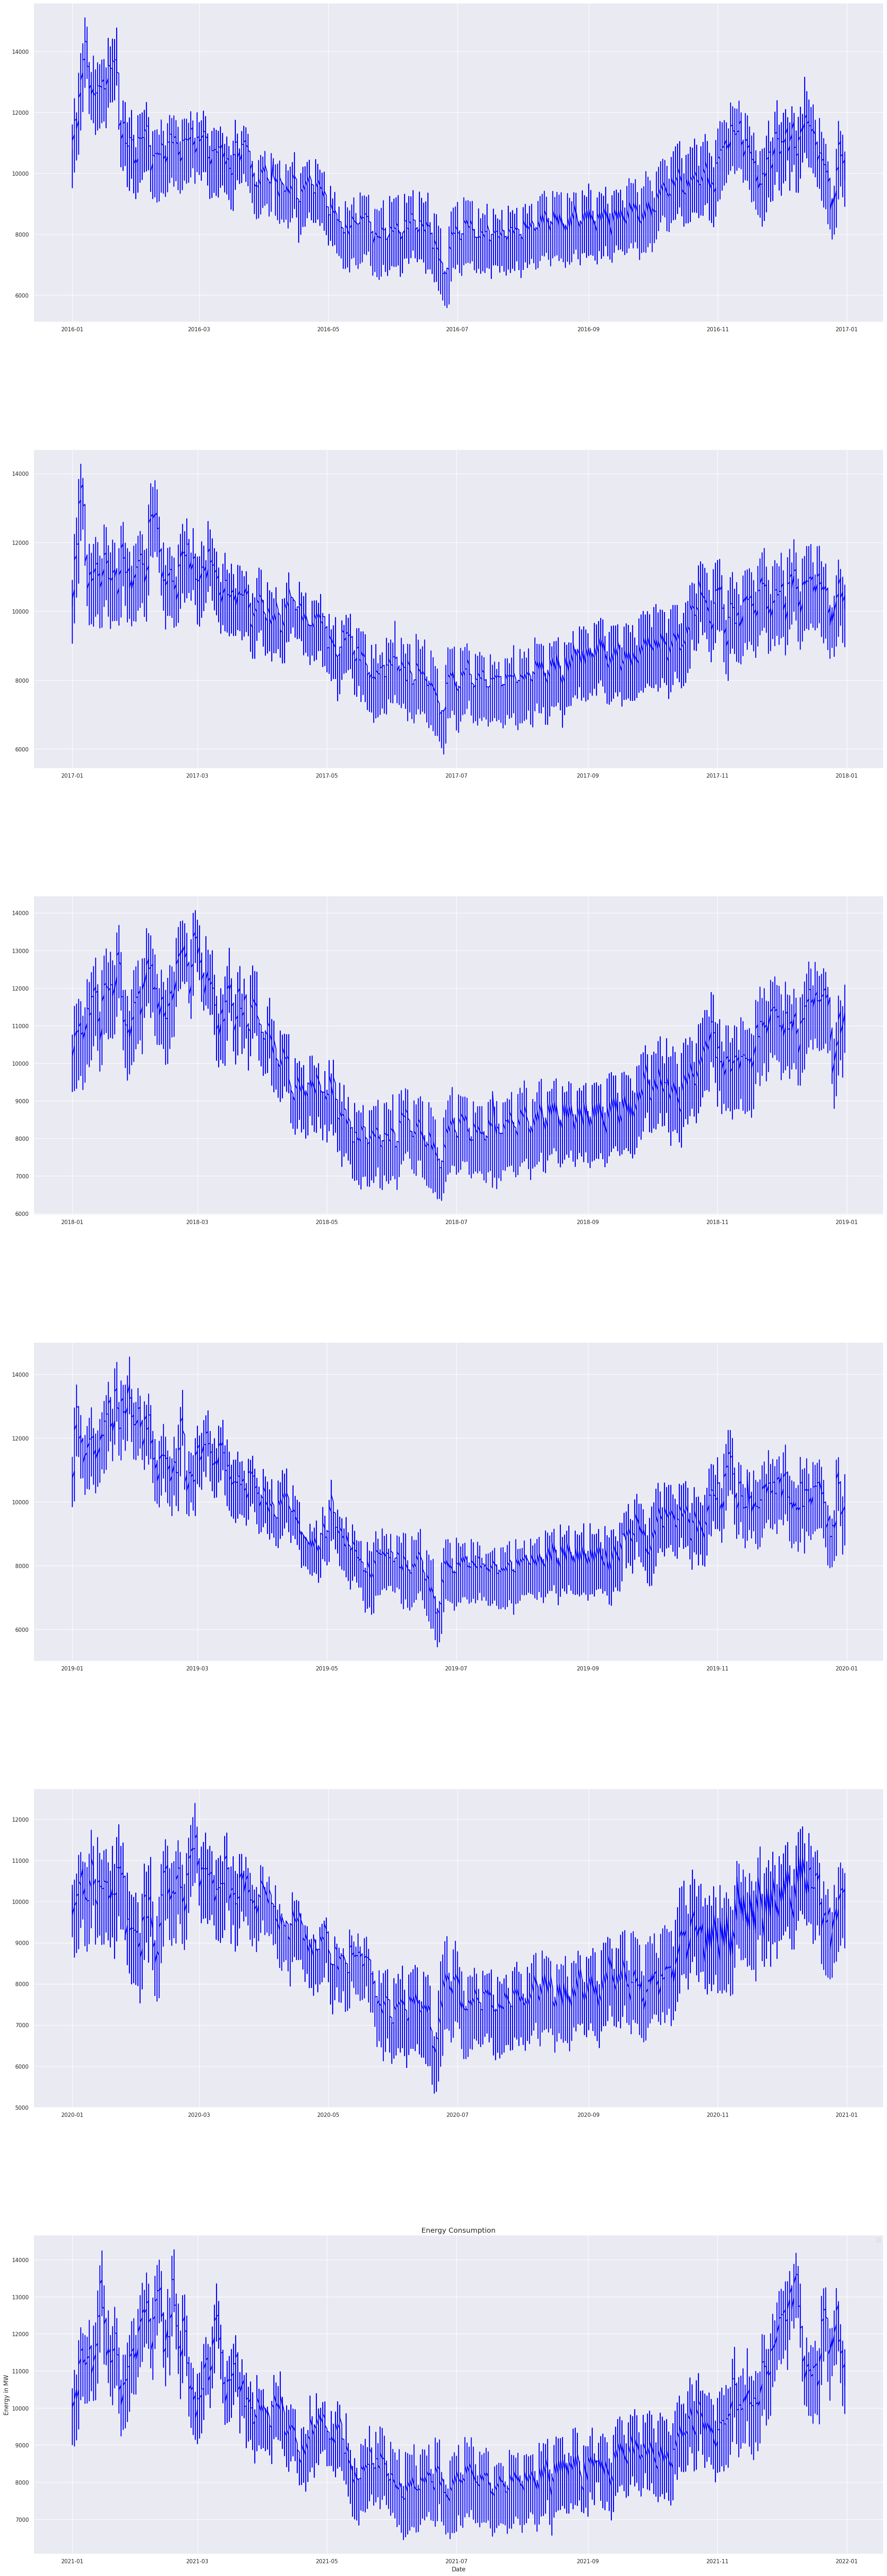

In [ ]:
# Energy Consumption Each Year
from matplotlib import style

fig = plt.figure(figsize = (30,30))

ax1 = fig.add_subplot(611)
ax2 = fig.add_subplot(612)
ax3 = fig.add_subplot(613)
ax4 = fig.add_subplot(614)
ax5 = fig.add_subplot(615)
ax6 = fig.add_subplot(616)

style.use("ggplot")

y_2016 = dataset.loc["2016"]["Consumption"].to_list()
x_2016 = dataset.loc["2016"]["Date"].to_list()
ax1.plot(x_2016, y_2016, color= "blue", linewidth= 1.7)

y_2017 = dataset.loc["2017"]["Consumption"].to_list()
x_2017 = dataset.loc["2017"]["Date"].to_list()
ax2.plot(x_2017, y_2017, color= "blue", linewidth= 1.7)

y_2018 = dataset.loc["2018"]["Consumption"].to_list()
x_2018 = dataset.loc["2018"]["Date"].to_list()
ax3.plot(x_2018, y_2018, color= "blue", linewidth= 1.7)

y_2019 = dataset.loc["2019"]["Consumption"].to_list()
x_2019 = dataset.loc["2019"]["Date"].to_list()
ax4.plot(x_2019, y_2019, color= "blue", linewidth= 1.7)

y_2020 = dataset.loc["2020"]["Consumption"].to_list()
x_2020 = dataset.loc["2020"]["Date"].to_list()
ax5.plot(x_2020, y_2020, color= "blue", linewidth= 1.7)

y_2021 = dataset.loc["2021"]["Consumption"].to_list()
x_2021 = dataset.loc["2021"]["Date"].to_list()
ax6.plot(x_2021, y_2021, color= "blue", linewidth= 1.7)

plt.rcParams["figure.figsize"] = (30, 15)
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=2.5, wspace=0.4, hspace=0.4)
plt.title("Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy in MW")
plt.grid(True, alpha=1)
plt.legend()

Text(0.5, 1.0, 'Energy Distribution')

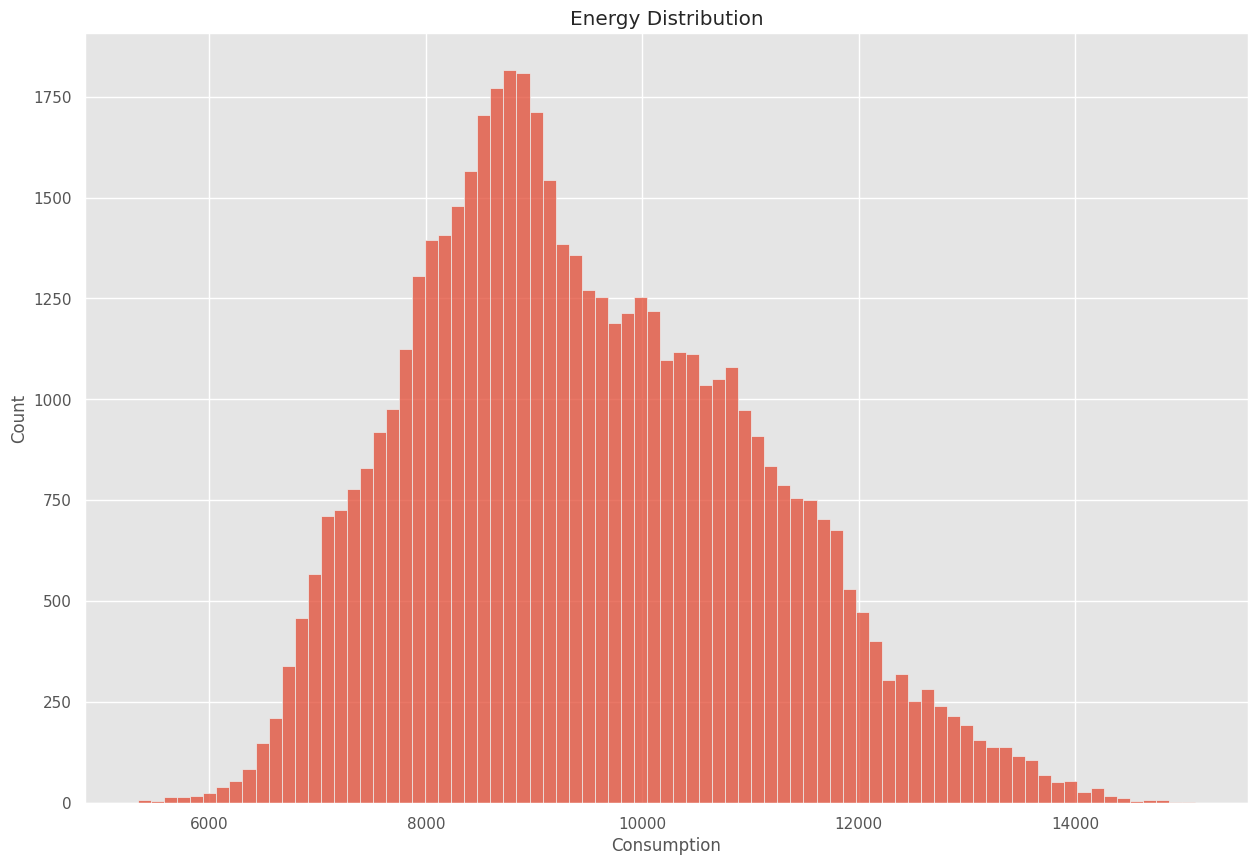

In [ ]:
# Lets us see the Distribution off Energy Consumption so we have a idea about your Dataset a bit more
fig = plt.figure(figsize = (15,10))
sns.histplot(dataset["Consumption"])
plt.title("Energy Distribution")

<ipython-input-17-0c5ad365e030>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


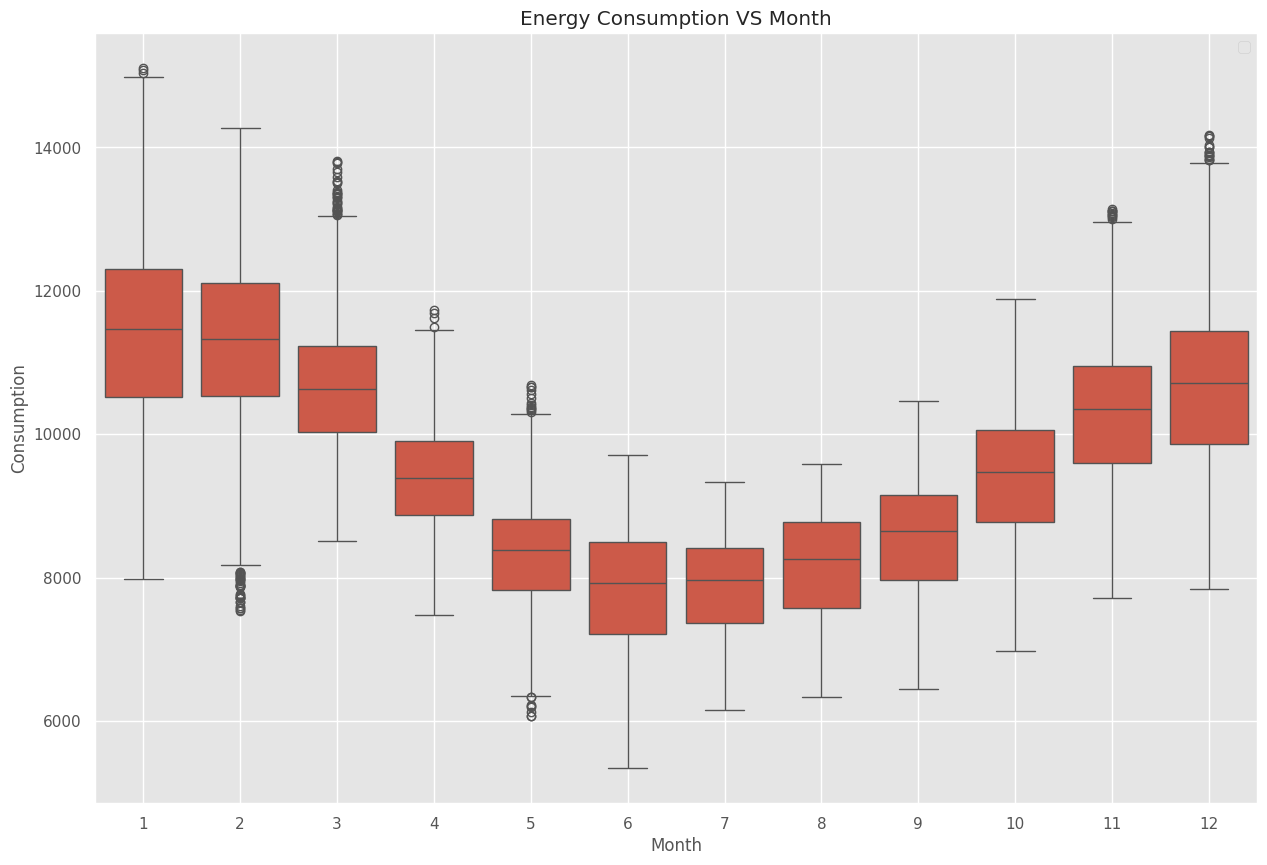

In [ ]:
fig = plt.figure(figsize = (15,10))
sns.boxplot(x=dataset["Month"], y=dataset["Consumption"], data= df)
plt.title("Energy Consumption VS Month")
plt.xlabel("Month")
plt.grid(True, alpha=1)
plt.legend()

for label in ax1.xaxis.get_ticklabels():
    label.set_rotation(90)

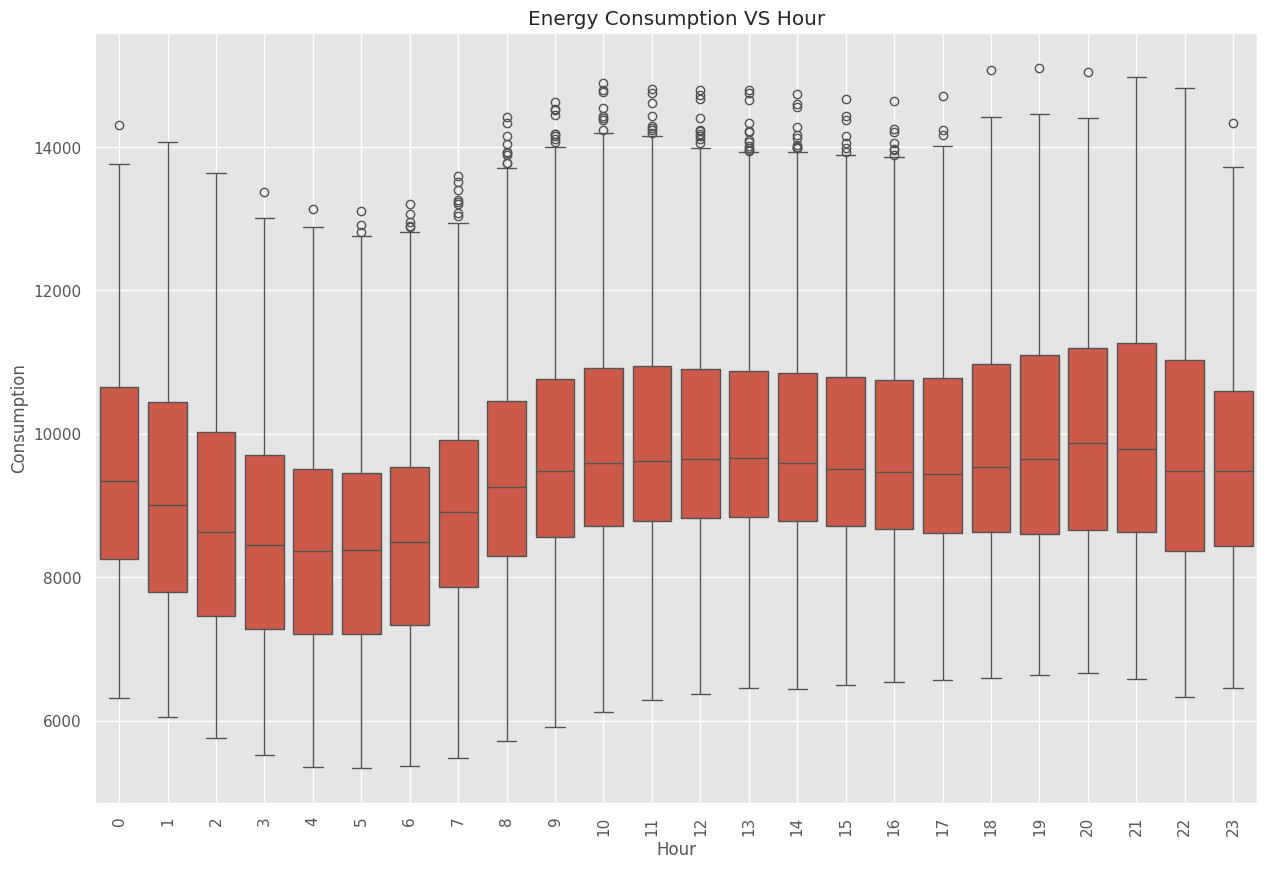

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

dataset1 = dataset.copy()
dataset1["Hour"] = dataset1.index.hour

plt.figure(figsize=(15, 10))
sns.boxplot(x="Hour", y="Consumption", data=dataset1)
plt.title("Energy Consumption VS Hour")
plt.xlabel("Hour")
plt.ylabel("Consumption")
plt.grid(True, alpha=1)

# Rotate x-axis labels
plt.xticks(rotation=90)
plt.show()


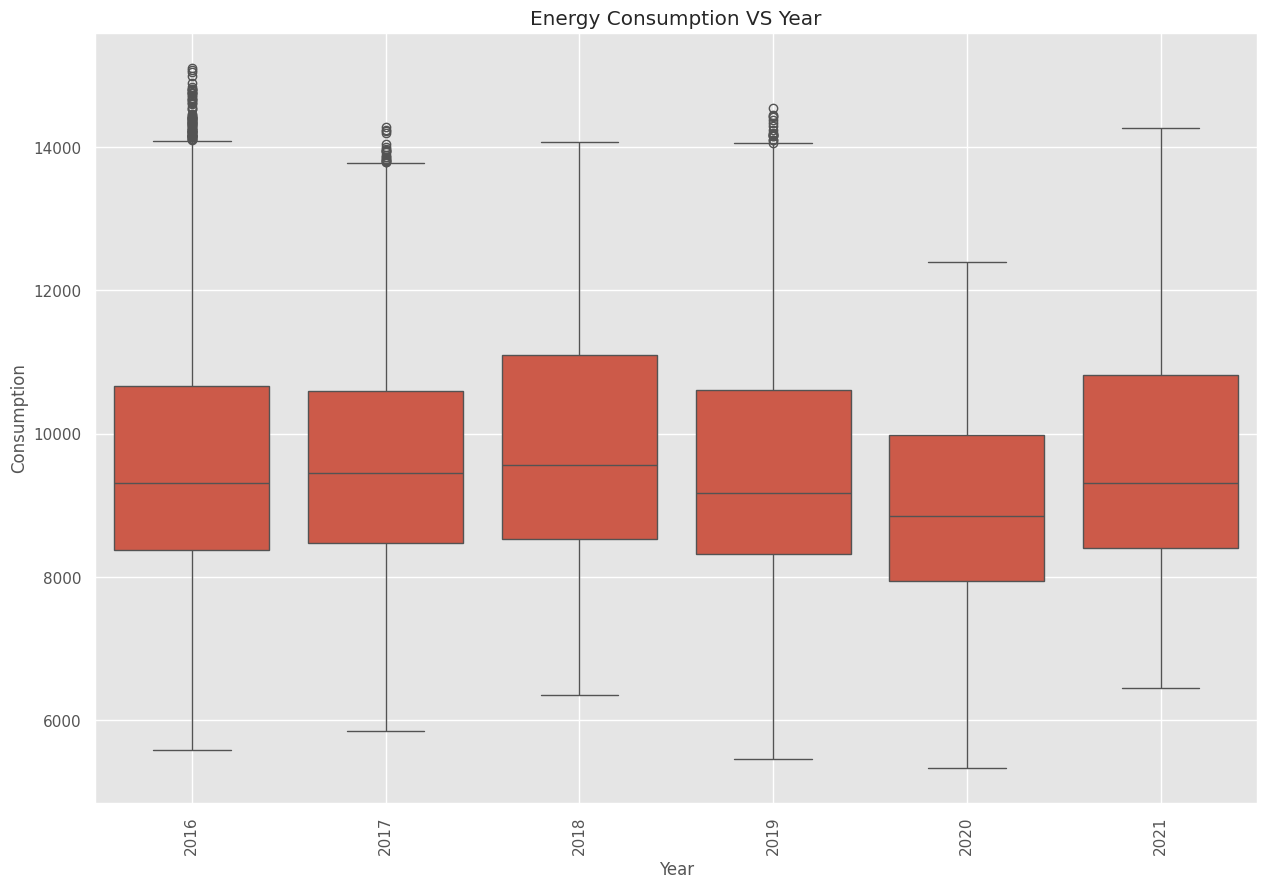

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the year column exists
dataset1["Year"] = dataset1.index.year

plt.figure(figsize=(15, 10))
sns.boxplot(x="Year", y="Consumption", data=dataset1)
plt.title("Energy Consumption VS Year")
plt.xlabel("Year")
plt.ylabel("Consumption")
plt.grid(True, alpha=1)
plt.xticks(rotation=90)
plt.show()


# LSTM Model

## Train, Validation and Test Dataset

In [ ]:
# Downsampling involves decreasing the time-frequency of the data
# Downsapling the time-frequency from hours to days
newDataSet = dataset.select_dtypes(include='number').resample("D").mean()

In [ ]:
# We have 2193 row
# 2193 - 3 - 6 = 2184 row after omit first two rows and last six ones.
# 2184 / 7 = 312 week
# 312 * 80 %  250 week for train (1750 day)
# 312 - 250 = 62 week for test (434 day)
print("Old Dataset: ", dataset.shape)
print("New Dataset: ", newDataSet.shape)

Old Dataset:  (52774, 7)
New Dataset:  (2184, 4)


In [ ]:
# Saving data in CSV new file
newDataSet.to_csv("newDataSet.csv")
from google.colab import files
files.download("newDataSet.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
newDataSet.head()

,Consumption,Month,Year,Week
DateTime,,,,
2016-01-01,10482.695652,1.0,2016.0,53.0
2016-01-02,11178.833333,1.0,2016.0,53.0
2016-01-03,11224.750000,1.0,2016.0,53.0
2016-01-04,12300.625000,1.0,2016.0,1.0
2016-01-05,12945.375000,1.0,2016.0,1.0


In [ ]:
y = newDataSet["Consumption"]
print(y[0])
y.shape

10482.695652173914


<ipython-input-19-8e8eaf141bc3>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(y[0])


(2193,)

In [ ]:
# Normalize data before model fitting
# it will boost the performance( in neural networks) + transform
from sklearn.preprocessing import MinMaxScaler
# scale of the output and input inthe range 0-1 to match the scale of the layer of LSTM
scaler = MinMaxScaler(feature_range = (0,1))
# reshape: convert the univariate 1D array into 2D
y = scaler.fit_transform(np.array(y).reshape(-1,1))
print("Normalizing data before model fitting")
print(y[:10])


Normalizing data before model fitting
[[0.53382758]
 [0.62011672]
 [0.62580828]
 [0.75916744]
 [0.83908687]
 [0.86975003]
 [1.        ]
 [0.98489309]
 [0.82500258]
 [0.78623593]]


In [ ]:
training_size = int(len(y)*0.80)
test_size = len(y)- training_size
val_size = int(training_size*0.20)
train_data , test_data , val_data = y[0:training_size-val_size,:] , y[training_size:len(y),:1], y[len(y)-test_size-val_size:len(y)-test_size,:1]


In [ ]:
# building input variable
def create_dataset(dataset, time_step = 1):
  dataX, dataY = [] , []
  for i in range(len(dataset)-time_step-1):
    a = dataset[i:(i+time_step),0]
    dataX.append(a)
    dataY.append(dataset[i + time_step,0])
  return np.array(dataX), np.array(dataY)


In [ ]:
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)
X_val, yval = create_dataset(val_data, time_step)


In [ ]:
# reshape train and input-output pairs
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1],1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1],1)

print("X_train shape: ", X_train.shape)
print("X_test shape: ",X_test.shape)
print("X_val shape: ",X_val.shape)


X_train shape:  (1303, 100, 1)
X_test shape:  (338, 100, 1)
X_val shape:  (249, 100, 1)


## Model Structure


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

model = Sequential()

# Adding the first LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50, return_sequences = True, input_shape = (time_step, 1)))
model.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50, return_sequences = True))
# model.add(Dropout(0.2))

# # Adding a third LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50, return_sequences = True))
# model.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularisation
model.add(LSTM(units = 50))
# model.add(Dropout(0.2))

# Adding the output layer
model.add(Dense(units = 1))

# Compiling the RNN
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val,yval), verbose = 1,epochs = 60 ,batch_size = 20)

Epoch 1/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - loss: 0.0576 - val_loss: 0.0056
Epoch 2/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - loss: 0.0074 - val_loss: 0.0045
Epoch 3/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 194ms/step - loss: 0.0077 - val_loss: 0.0051
Epoch 4/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - loss: 0.0066 - val_loss: 0.0041
Epoch 5/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - loss: 0.0061 - val_loss: 0.0046
Epoch 6/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - loss: 0.0064 - val_loss: 0.0039
Epoch 7/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 203ms/step - loss: 0.0057 - val_loss: 0.0041
Epoch 8/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - loss: 0.0055 - val_loss: 0.0035
Epoch 9/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 233ms/step - loss: 0.0047 - val_loss: 0.0038
Epoch 10/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - loss: 0.0050 - val_loss: 0.0033
Epoch 11/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - loss: 0.0050 - val_loss: 0.0041
Epoch 12/60
65/65 ━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
# # How to save your model in Google Drive
import torch
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
 model_save_name = 'LSTM-Model2022.h5'
 path = F"/content/gdrive/My Drive/{model_save_name}"
 torch.save(model, path)

## Model Evaluating

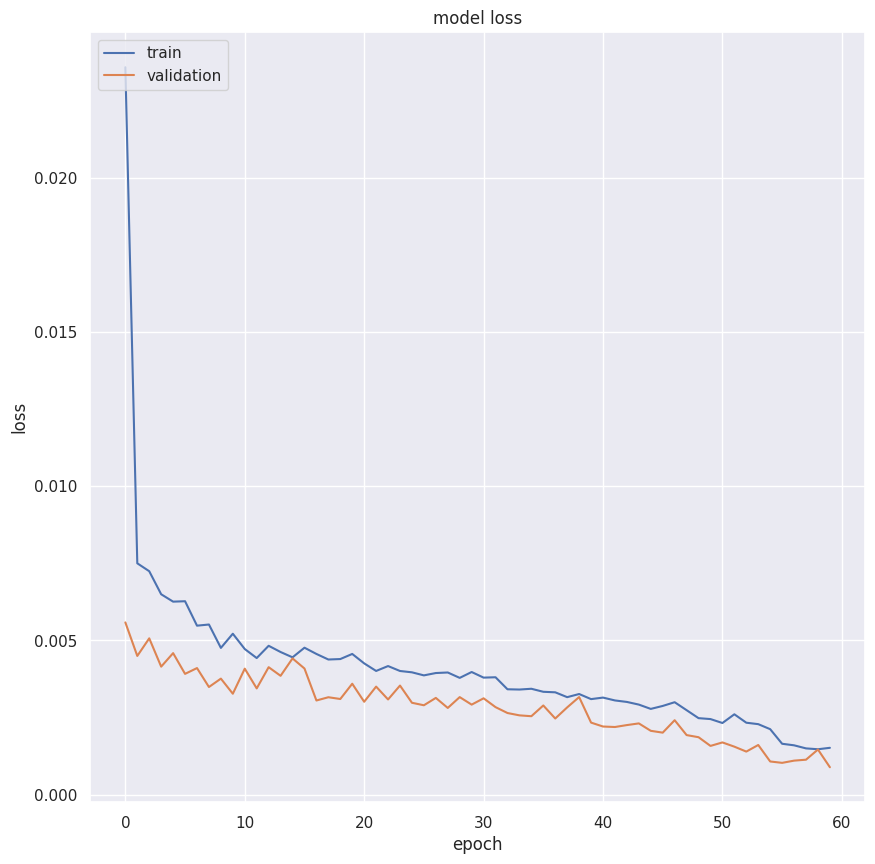

In [ ]:
plt.figure(figsize=(10,10))
plt.plot(history.history['loss']) # tb
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


In [ ]:
import tensorflow as tf
tf.__version__

'2.18.0'

In [ ]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)
val_predict=model.predict(X_val)


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [ ]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)
val_predict=scaler.inverse_transform(val_predict)

In [ ]:
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

9533.657795122093

In [ ]:
print(train_predict.shape)
print(test_predict.shape)
print(val_predict.shape)
print(train_predict[0])
print(y_train.shape)


(1297, 1)
(336, 1)
(248, 1)
[9470.665]
(1297, 1)


# Conclusion

In [ ]:
# TRAIN
train_predictions = model.predict(X_train)
train_predictions = scaler.inverse_transform(train_predictions)
y_train = y_train.reshape(y_train.shape[0], 1)
y_train_actual = scaler.inverse_transform(y_train)

train_results = pd.DataFrame()
train_results["Train Predictions"] = train_predictions.flatten()
train_results["Actuals"] = y_train_actual.flatten()

# VALIDATION
val_predictions = model.predict(X_val)
val_predictions = scaler.inverse_transform(val_predictions)
y_val = yval.reshape(yval.shape[0], 1)
y_val_actual = scaler.inverse_transform(y_val)

val_results = pd.DataFrame()
val_results["Validation Predictions"] = val_predictions.flatten()
val_results["Actuals"] = y_val_actual.flatten()

# TEST
test_predictions = model.predict(X_test)
test_predictions = scaler.inverse_transform(test_predictions)
y_test = ytest.reshape(ytest.shape[0], 1)
y_test_actual = scaler.inverse_transform(y_test)

test_results = pd.DataFrame()
test_results["Test Predictions"] = test_predictions.flatten()
test_results["Actuals"] = y_test_actual.flatten()


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {label} Evaluation:")
    print(f"RMSE     : {rmse:.4f}")
    print(f"R² Score : {r2:.4f}")

# Evaluate for all sets
evaluate_model(y_train_actual, train_predictions, label="Train")
evaluate_model(y_val_actual, val_predictions, label="Validation")
evaluate_model(y_test_actual, test_predictions, label="Test")



📊 Train Evaluation:
RMSE     : 274.7928
R² Score : 0.9640

📊 Validation Evaluation:
RMSE     : 240.2762
R² Score : 0.9547

📊 Test Evaluation:
RMSE     : 301.6470
R² Score : 0.9612


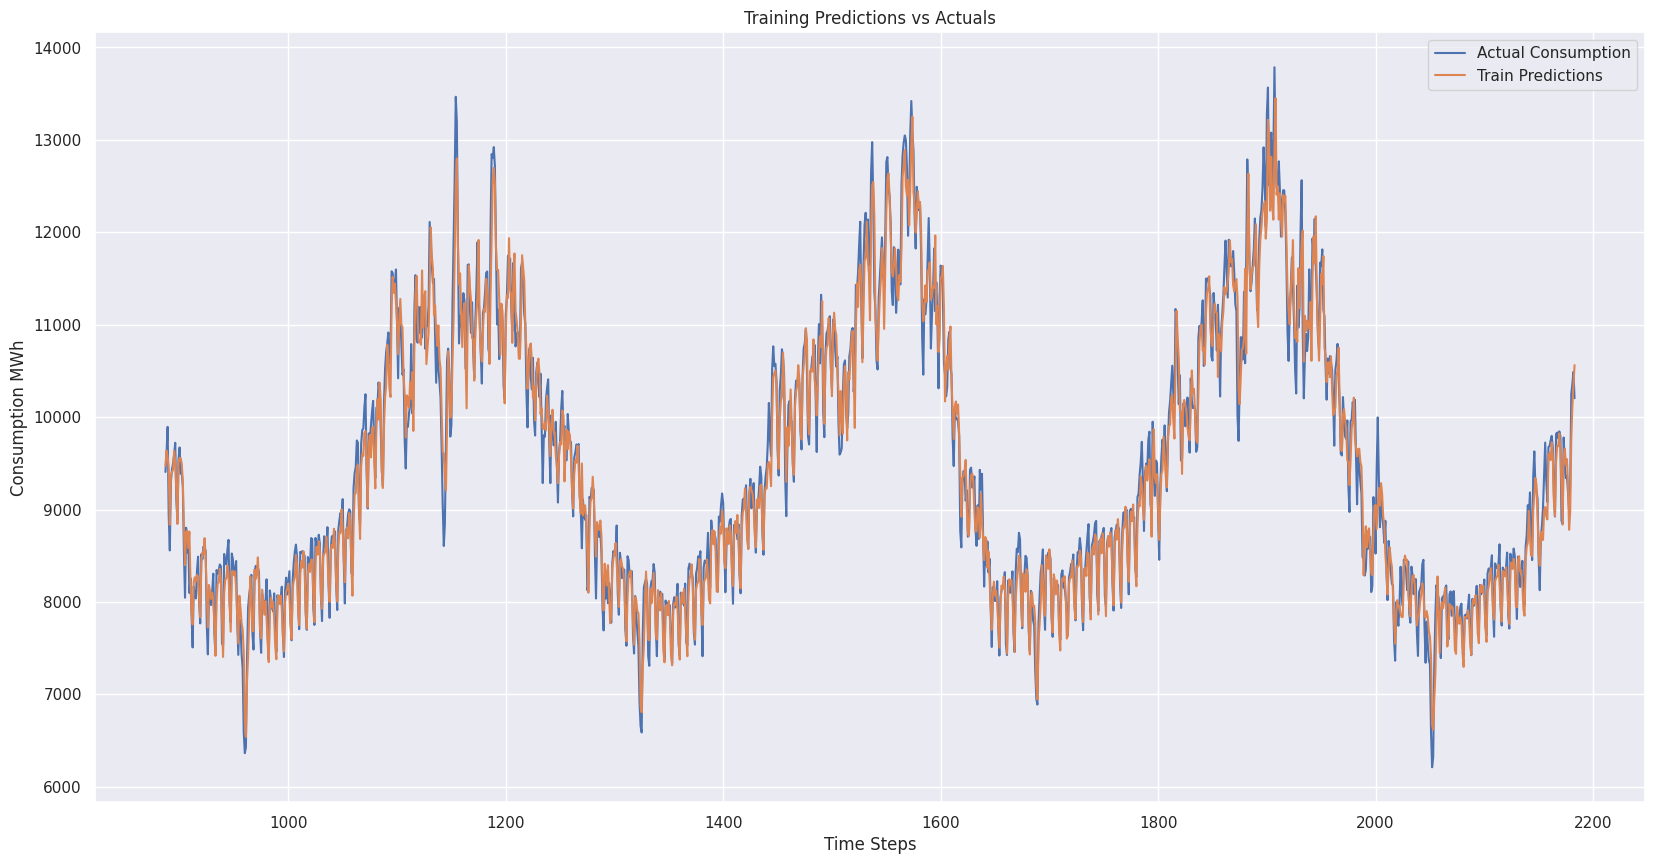

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20,10))

# Actual Consumption
ActualPlot = np.empty_like(y)
ActualPlot[:, :] = np.nan
ActualPlot[887:, :] = y_train_actual.reshape(-1, 1)
plt.plot(ActualPlot)

# Train Predictions
TrainPredictionsPlot = np.empty_like(y)
TrainPredictionsPlot[:, :] = np.nan
TrainPredictionsPlot[887:, :] = train_predictions.reshape(-1, 1)
plt.plot(TrainPredictionsPlot)

plt.legend(['Actual Consumption', 'Train Predictions'])
plt.xlabel('Time Steps')
plt.ylabel('Consumption MWh')
plt.title('Training Predictions vs Actuals')
plt.show()


In [ ]:
# Predicting consumption using validation data
val_predictions = model.predict(X_val)
val_predictions =scaler.inverse_transform(val_predictions)

yval = yval.reshape(yval.shape[0], 1)
actual_val = scaler.inverse_transform(yval)

val_results = pd.DataFrame()
val_results["Val Predictions"] = val_predictions.tolist()
val_results["Actuals_val"] = actual_val.tolist()

val_results


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


,Val Predictions,Actuals_val
0,[9208.7392578125],[8931.875]
1,[9168.9208984375],[9112.916666666666]
2,[9199.0673828125],[10019.416666666666]
3,[10037.6708984375],[10390.375]
4,[10354.837890625],[10802.916666666666]
...,...,...
243,[8030.1142578125],[8020.541666666667]
244,[7748.08349609375],[7921.75]
245,[8410.83984375],[8705.041666666666]
246,[8683.943359375],[8824.708333333334]


Text(0, 0.5, 'Consumption MWh')

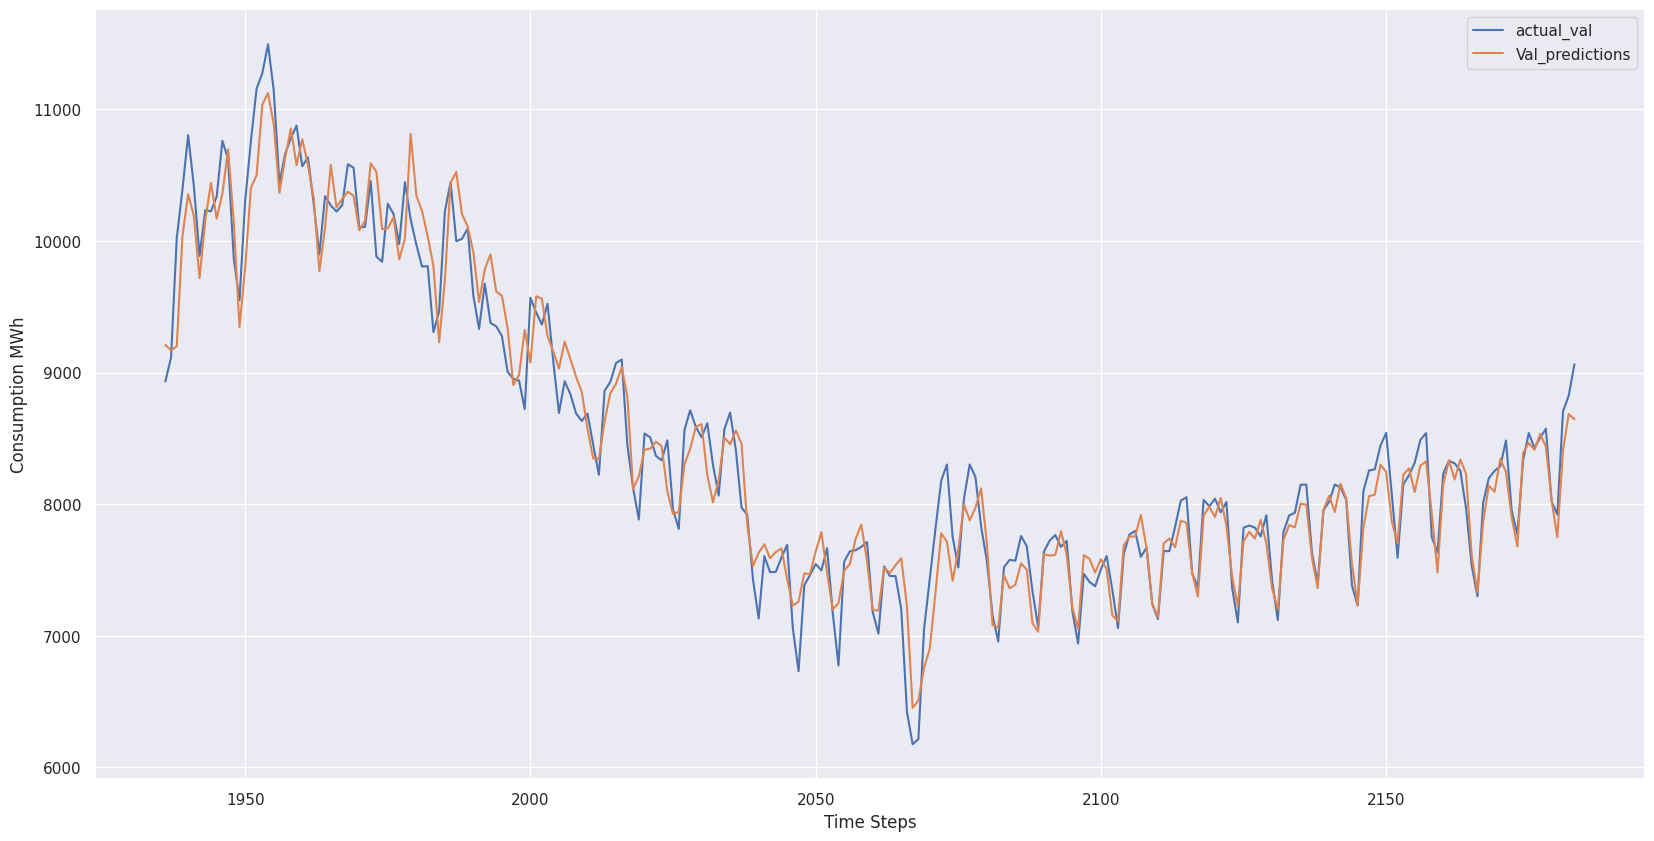

In [ ]:
plt.figure(figsize=(20,10))

# Actual Consumption
ActualPlot = np.empty_like(y)
ActualPlot[:, :] = np.nan
ActualPlot[1936:, :] = actual_val.tolist()
plt.plot(ActualPlot)

# Validation Prediction
ValPredictionsPlot = np.empty_like(y)
ValPredictionsPlot[:, :] = np.nan
ValPredictionsPlot[1936:, :] = val_predictions.tolist()
plt.plot(ValPredictionsPlot)

plt.legend(['actual_val','Val_predictions'])
plt.xlabel('Time Steps')
plt.ylabel('Consumption MWh')


In [ ]:
# Predicting consumption using test data
test_predictions = model.predict(X_test)
test_predictions =scaler.inverse_transform(test_predictions)

ytest = ytest.reshape(ytest.shape[0], 1)
actual_test = scaler.inverse_transform(ytest)

test_results = pd.DataFrame()
test_results["test Predictions"] = test_predictions.tolist()
test_results["Actuals_test"] = actual_test.tolist()

test_results

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


,test Predictions,Actuals_test
0,[10465.6875],[10032.541666666666]
1,[10681.078125],[10732.125]
2,[10856.3876953125],[10733.583333333334]
3,[10714.2138671875],[10971.875]
4,[11155.0947265625],[11227.791666666666]
...,...,...
331,[12324.36328125],[12540.25]
332,[12584.4716796875],[12635.958333333334]
333,[12673.4091796875],[11684.333333333334]
334,[11104.6630859375],[11384.166666666666]


Text(0, 0.5, 'Consumption MWh')

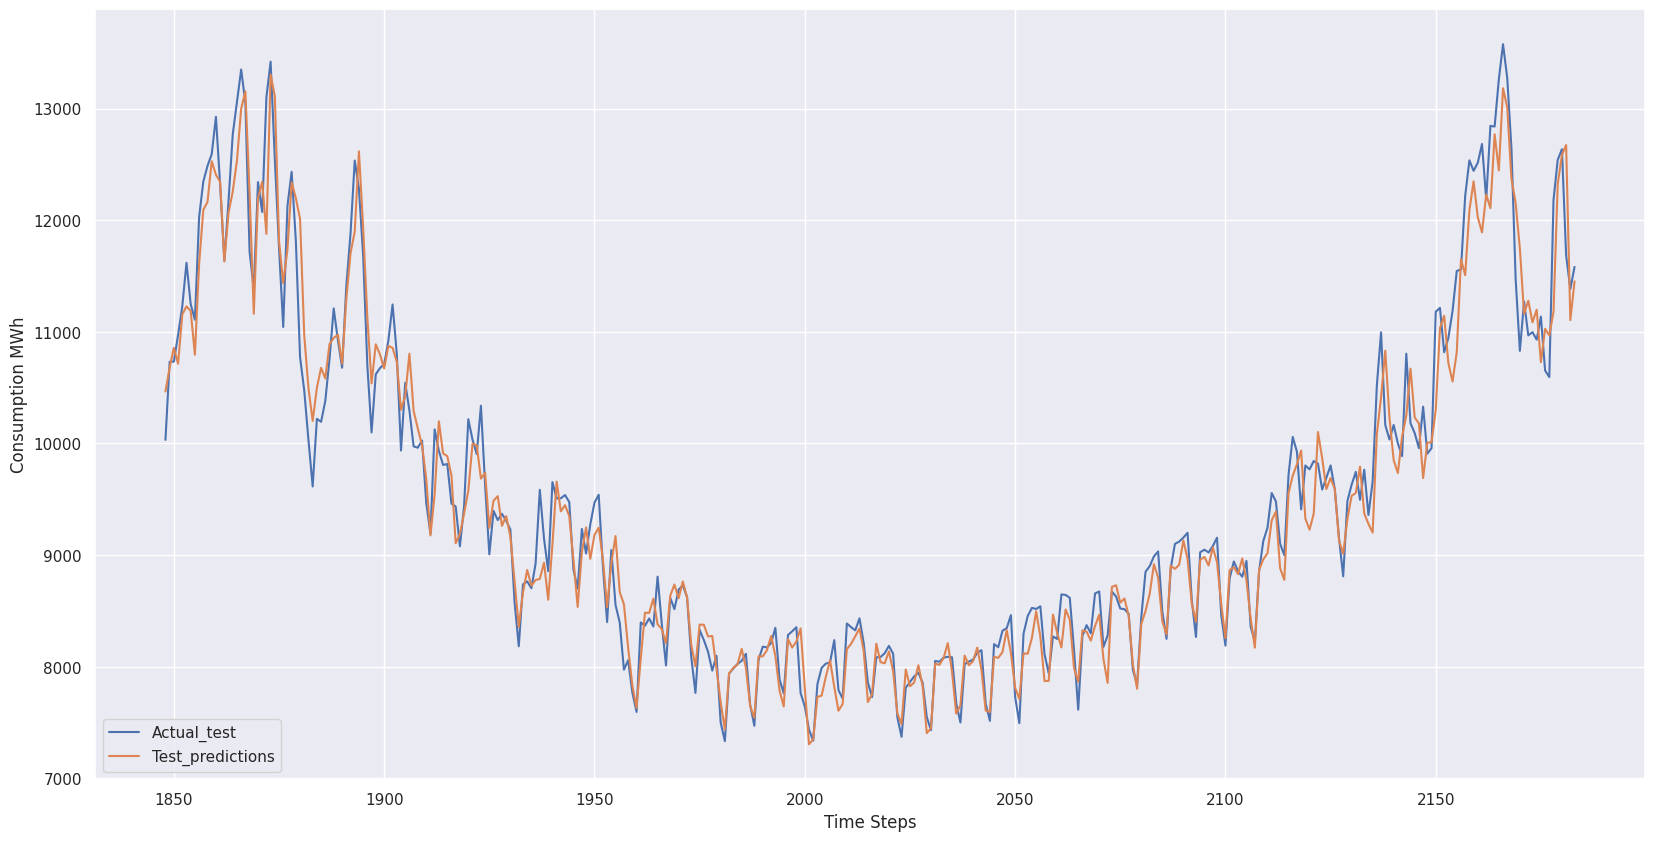

In [ ]:
plt.figure(figsize=(20,10))

# Actual Consumption
ActualPlot = np.empty_like(y)
ActualPlot[:, :] = np.nan
ActualPlot[1848:, :] = actual_test.tolist()
plt.plot(ActualPlot)

# Test Prediction
TestPredictionsPlot = np.empty_like(y)
TestPredictionsPlot[:, :] = np.nan
TestPredictionsPlot[1848:, :] = test_predictions.tolist()
plt.plot(TestPredictionsPlot)

plt.legend(['Actual_test','Test_predictions'])
plt.xlabel('Time Steps')
plt.ylabel('Consumption MWh')

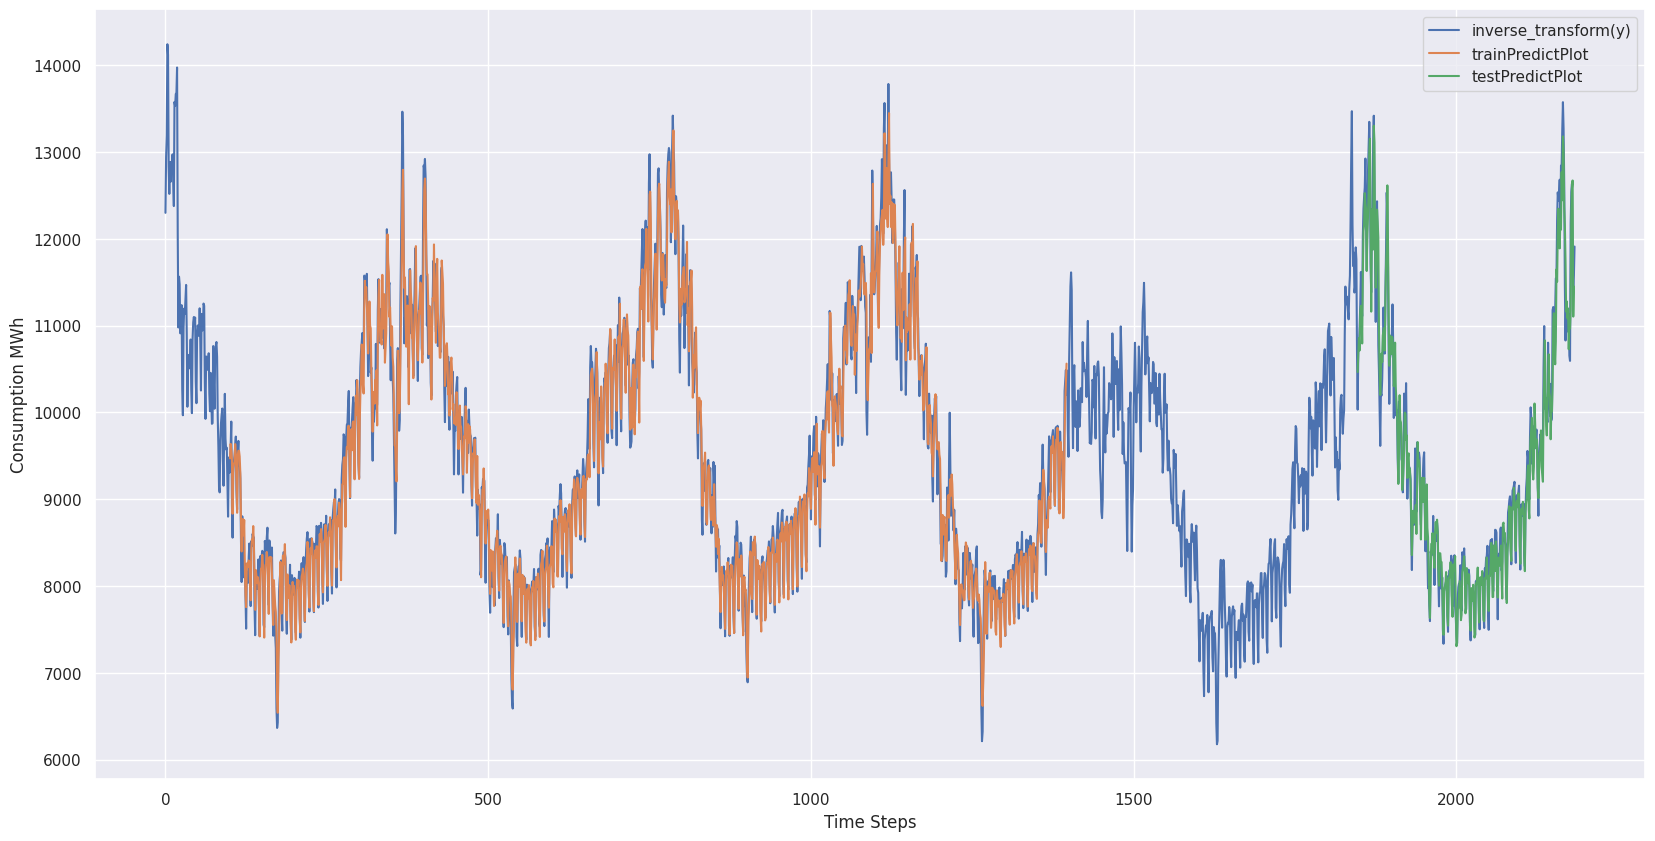

In [ ]:
### Plotting
# shift train predictions for plotting
look_back=100 #*****************************************>>>>>100
fig, ax = plt.subplots(figsize=(20,10))
trainPredictPlot = np.empty_like(y)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(y)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1+349:len(y)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(y))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.legend(['inverse_transform(y)','trainPredictPlot','testPredictPlot'])
plt.xlabel('Time Steps')
plt.ylabel('Consumption MWh')
plt.show()

# Future forecasting

In [ ]:
print(len(test_data))
print(test_data[0])
print(len(train_data))
x_input=test_data[337:].reshape(1,-1)
print(x_input.shape)
# print(x_input[0])
temp_input=list(x_input)
temp_input=temp_input[0].tolist()
# print(temp_input)

437
[0.40285095]
1398
(1, 100)


In [ ]:

# demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
test = ""
while(i<30):

    if(len(temp_input)>100):
        test = "if"
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        test="else"
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        #print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        #print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(test)
print(len(lst_output))

1 day input [0.25709121 0.33563165 0.36255552 0.36498812 0.36948662 0.37489412
 0.30034604 0.25916744 0.35327446 0.35606342 0.3529749  0.36009193
 0.36937816 0.28358124 0.249561   0.32426919 0.3429811  0.33217643
 0.32601487 0.34354922 0.27053507 0.25411631 0.33202665 0.36575767
 0.38037909 0.41900114 0.40965809 0.36264332 0.34998967 0.43912819
 0.48126743 0.46479186 0.40083153 0.44962814 0.44524842 0.45453466
 0.45160624 0.42284888 0.4359467  0.44960748 0.42327755 0.3690941
 0.3264797  0.41017457 0.42818407 0.44249561 0.41147609 0.44483008
 0.39457184 0.43183555 0.53842578 0.59736597 0.49454602 0.47844231
 0.49448921 0.47407293 0.45992666 0.57367524 0.49652928 0.4854922
 0.46876872 0.51486933 0.46267431 0.46884619 0.620282   0.62459457
 0.57526598 0.59118893 0.62118583 0.6655046  0.66726578 0.74881727
 0.7883793  0.77671212 0.78571429 0.80647144 0.74484041 0.82660366
 0.82588059 0.87828737 0.91723995 0.87967669 0.80140998 0.65632683
 0.57681025 0.63147402 0.59401921 0.59759839 0.58928

2184
[[12048.3289818 ]
 [12116.26783441]
 [12346.29801999]
 [12341.39035801]
 [11878.94684235]
 [11584.50443486]
 [12087.83263127]
 [12274.78156547]
 [12277.9562063 ]
 [12452.02673535]
 [12404.50810353]
 [11927.1098272 ]
 [11615.69112162]
 [12062.51917432]
 [12234.83840952]
 [12228.52952013]
 [12362.26258765]
 [12272.44843046]
 [11788.88263772]
 [11492.43985067]
 [11911.65016303]
 [12064.11947797]
 [12051.45265142]
 [12152.40449886]
 [12024.06476239]
 [11536.47512923]
 [11270.13324598]
 [11677.14605163]
 [11789.57700024]
 [11765.28585265]]


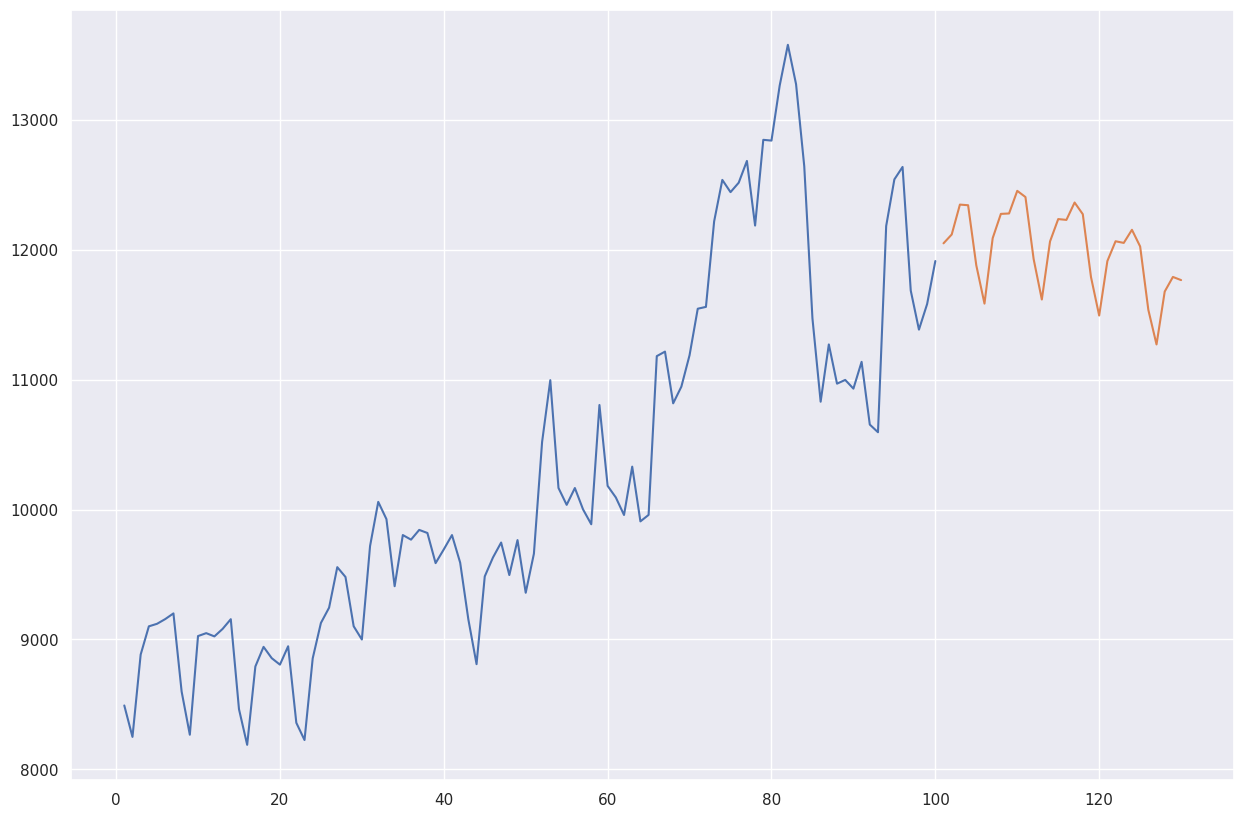

In [ ]:
print(len(y))
day_new=np.arange(1,101)
day_pred=np.arange(101, 131 )
plt.figure(figsize = (15,10))
plt.plot(day_new,scaler.inverse_transform(y[2084:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))
print(scaler.inverse_transform(lst_output))

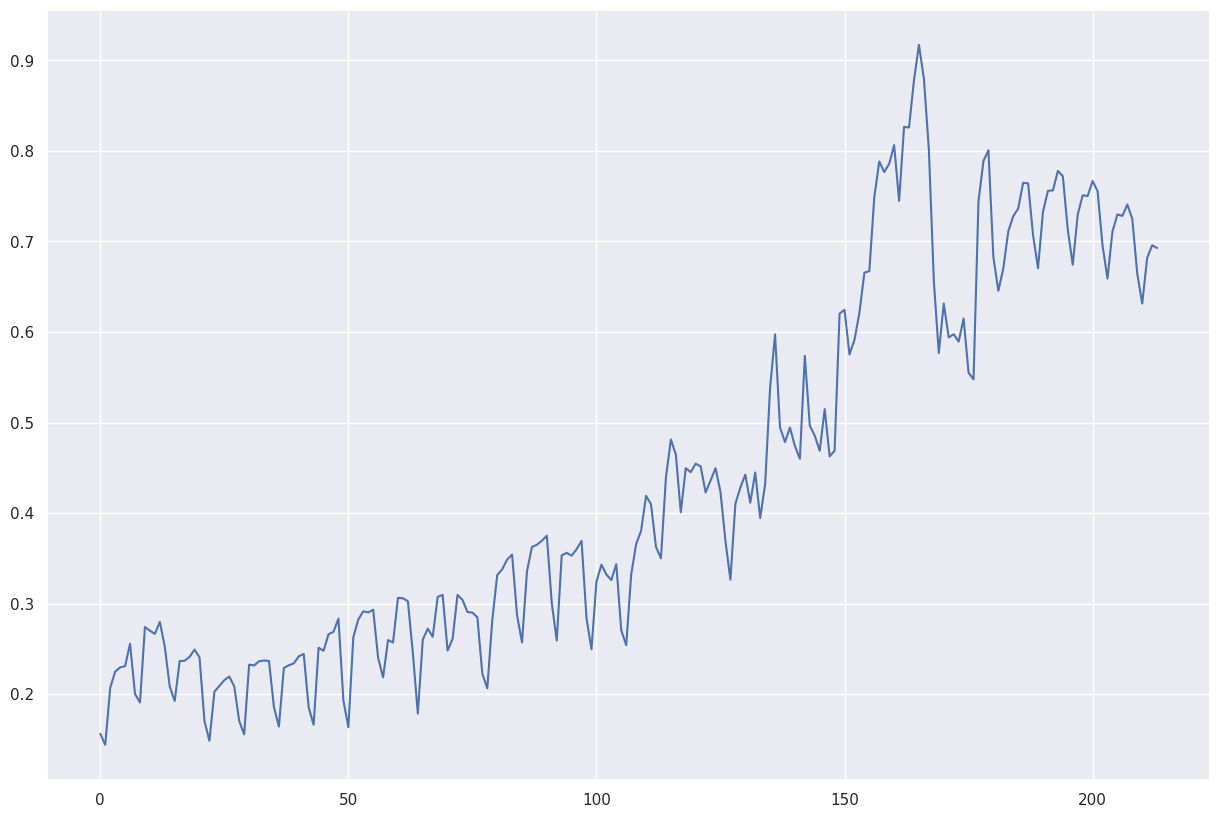

In [ ]:
df3=y.tolist()
df3.extend(lst_output)
plt.figure(figsize=(15,10))
plt.plot(df3[2000:])



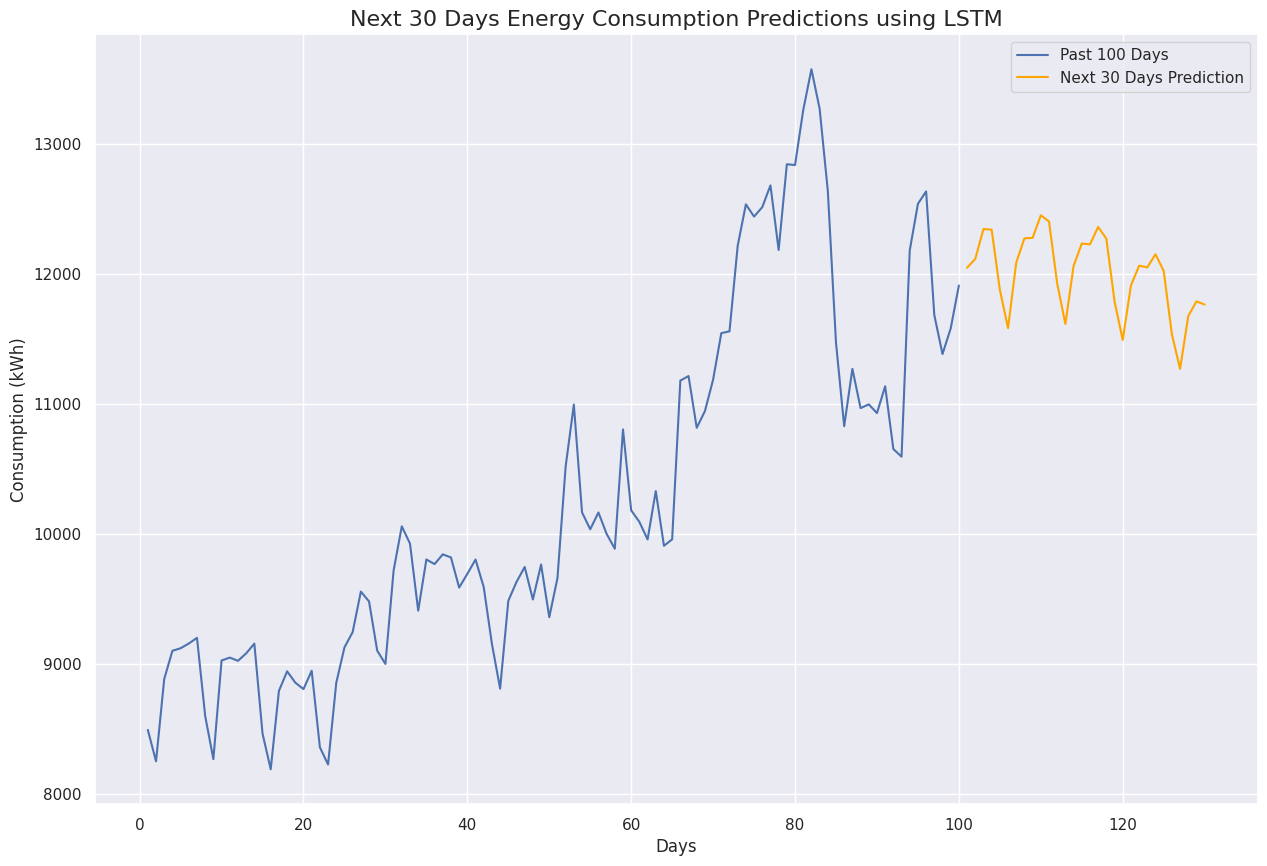

Next 30 Days Predicted Values:
[[12048.3289818 ]
 [12116.26783441]
 [12346.29801999]
 [12341.39035801]
 [11878.94684235]
 [11584.50443486]
 [12087.83263127]
 [12274.78156547]
 [12277.9562063 ]
 [12452.02673535]
 [12404.50810353]
 [11927.1098272 ]
 [11615.69112162]
 [12062.51917432]
 [12234.83840952]
 [12228.52952013]
 [12362.26258765]
 [12272.44843046]
 [11788.88263772]
 [11492.43985067]
 [11911.65016303]
 [12064.11947797]
 [12051.45265142]
 [12152.40449886]
 [12024.06476239]
 [11536.47512923]
 [11270.13324598]
 [11677.14605163]
 [11789.57700024]
 [11765.28585265]]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


day_new = np.arange(1, 101)
day_pred = np.arange(101, 131)

plt.figure(figsize=(15, 10))

# Plotting actual and predicted values
plt.plot(day_new, scaler.inverse_transform(y[2084:]), label="Past 100 Days")
plt.plot(day_pred, scaler.inverse_transform(lst_output), color='orange', label="Next 30 Days Prediction")

# Adding title and labels
plt.title("Next 30 Days Energy Consumption Predictions using LSTM", fontsize=16)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Consumption (kWh)", fontsize=12)
plt.legend()

# Show plot
plt.show()

# Print next 30 days predicted values
print("Next 30 Days Predicted Values:")
print(scaler.inverse_transform(lst_output))